# Deep Hedging – Phase 1 Notebook

This notebook prepares a dataset and an evaluation pipeline aligned with the paper structure.

The setting keeps the same level of complexity as the article:
a spread option payoff, two tradable forwards, one non-tradable factor, discrete hedging dates and liquidity constraints.

The default dataset is a modified version of the paper's Case 2.
This satisfies the project instruction to change the dataset while keeping the modelling structure close to the article.


## What is produced

This notebook generates simulated paths for the tradable forwards and the non-tradable factor.
It computes the spread option payoff.
It creates train, validation and test splits.
It defines the expected format of the hedging strategies.
It implements the financial evaluation pipeline used later to compute terminal portfolio value, hedging error and net PnL.


In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## Configuration

The helper below provides two configurations.

`paper_case2_exact` reproduces the structure and numerical values of Case 2 reported in the article.
`paper_case2_modified` keeps the same complexity but changes some dataset parameters:
the maturity, the number of hedging dates and the liquidity level.
The modified version is selected by default for the project dataset.


In [2]:
def get_config(case_name="paper_case2_modified"):
    if case_name == "paper_case2_exact":
        return {
            "case_name": "paper_case2_exact",
            "T_days": 90.0,
            "N": 14,
            "strike": 10.0,
            "liquidity": np.array([0.2, 0.2], dtype=float),
            "F0": np.array([40.0, 30.0], dtype=float),
            "sigma_E": np.array([0.004136, 0.003137], dtype=float),
            "a_E": np.array([0.0002, 0.0001], dtype=float),
            "V0": 1.0,
            "V_bar": 1.0,
            "sigma_V": 0.02,
            "a_V": 0.02,
            "corr_matrix": np.array([
                [1.0, 0.7, 0.2],
                [0.7, 1.0, 0.2],
                [0.2, 0.2, 1.0]
            ], dtype=float),
            "transaction_costs": np.array([0.02, 0.02], dtype=float),
            "n_train": 20000,
            "n_val": 5000,
            "n_test": 5000,
            "seed": 42,
            "stationary_x0": False,
        }

    if case_name == "paper_case2_modified":
        return {
            "case_name": "paper_case2_modified",
            "T_days": 120.0,
            "N": 20,
            "strike": 11.0,
            "liquidity": np.array([0.15, 0.15], dtype=float),
            "F0": np.array([40.0, 30.0], dtype=float),
            "sigma_E": np.array([0.0044, 0.0033], dtype=float),
            "a_E": np.array([0.0002, 0.0001], dtype=float),
            "V0": 1.0,
            "V_bar": 1.0,
            "sigma_V": 0.022,
            "a_V": 0.02,
            "corr_matrix": np.array([
                [1.0, 0.65, 0.2],
                [0.65, 1.0, 0.2],
                [0.2, 0.2, 1.0]
            ], dtype=float),
            "transaction_costs": np.array([0.02, 0.02], dtype=float),
            "n_train": 20000,
            "n_val": 5000,
            "n_test": 5000,
            "seed": 42
        }

    if case_name == "hard_volume":

        return {
            "case_name": "hard_volume",
            "T_days": 120.0,
            "N": 20,
            "strike": 11.0,
            "liquidity": np.array([0.15, 0.15], dtype=float),
            "F0": np.array([40.0, 30.0], dtype=float),
            "sigma_E": np.array([0.0044, 0.0033], dtype=float),
            "a_E": np.array([0.0002, 0.0001], dtype=float),
            "V0": 1.0,
            "V_bar": 1.0,
            "sigma_V": 0.10,   
            "a_V": 0.02,
            "corr_matrix": np.array([
                [1.0, 0.2, 0.2],
                [0.2, 1.0, 0.2],
                [0.2, 0.2, 1.0]
            ], dtype=float),
            "transaction_costs": np.array([0.02, 0.02], dtype=float),
            "n_train": 20000,
            "n_val": 5000,
            "n_test": 5000,
            "seed": 42,
            "stationary_x0": False,
        }

    raise ValueError("Unknown case name")

CONFIG = get_config("paper_case2_modified")
CONFIG


{'case_name': 'paper_case2_modified',
 'T_days': 120.0,
 'N': 20,
 'strike': 11.0,
 'liquidity': array([0.15, 0.15]),
 'F0': array([40., 30.]),
 'sigma_E': array([0.0044, 0.0033]),
 'a_E': array([0.0002, 0.0001]),
 'V0': 1.0,
 'V_bar': 1.0,
 'sigma_V': 0.022,
 'a_V': 0.02,
 'corr_matrix': array([[1.  , 0.65, 0.2 ],
        [0.65, 1.  , 0.2 ],
        [0.2 , 0.2 , 1.  ]]),
 'transaction_costs': array([0.02, 0.02]),
 'n_train': 20000,
 'n_val': 5000,
 'n_test': 5000,
 'seed': 42}

## Output folders

In [3]:
BASE_DIR = Path("deep_hedging_phase1_paper_aligned")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
OUTPUT_DIR = BASE_DIR / "model_outputs"

for folder in [DATA_DIR, RESULTS_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BASE_DIR.resolve()


PosixPath('/Users/user/Desktop/ML/Machine-Learning-in-Finance-Project/deep_hedging_phase1_paper_aligned')

## Simulation model

The tradable assets follow the forward-price representation used in the paper.
A latent Ornstein-Uhlenbeck factor is simulated for each tradable asset.
The non-tradable factor follows a mean-reverting process.

The Brownian shocks driving the two tradable assets and the non-tradable factor are correlated.


In [4]:
def _ou_step(x_prev, a, sigma, dt, z):
    if a <= 0:
        return x_prev + sigma * np.sqrt(dt) * z
    exp_term = np.exp(-a * dt)
    variance_term = (1.0 - np.exp(-2.0 * a * dt)) / (2.0 * a)
    return exp_term * x_prev + sigma * np.sqrt(variance_term) * z


def simulate_paper_like_paths(config):
    rng = np.random.default_rng(config["seed"])

    T_days = config["T_days"]
    N = config["N"]
    dt_days = T_days / N
    time_days = np.linspace(0.0, T_days, N + 1)

    n_total = config["n_train"] + config["n_val"] + config["n_test"]

    corr = config["corr_matrix"]
    chol = np.linalg.cholesky(corr)

    shocks = rng.standard_normal(size=(n_total, N, 3))
    shocks = shocks @ chol.T

    d = 2
    x_factors = np.zeros((n_total, N + 1, d), dtype=np.float64)
    tradable_paths = np.zeros((n_total, N + 1, d), dtype=np.float64)
    volume_paths = np.zeros((n_total, N + 1), dtype=np.float64)

    tradable_paths[:, 0, :] = config["F0"]
    volume_paths[:, 0] = config["V0"]

    for t in range(N):
        for j in range(d):
            x_factors[:, t + 1, j] = _ou_step(
                x_prev=x_factors[:, t, j],
                a=config["a_E"][j],
                sigma=config["sigma_E"][j],
                dt=dt_days,
                z=shocks[:, t, j]
            )

        volume_paths[:, t + 1] = (
            config["V_bar"]
            + (volume_paths[:, t] - config["V_bar"]) * np.exp(-config["a_V"] * dt_days)
            + config["sigma_V"]
            * np.sqrt((1.0 - np.exp(-2.0 * config["a_V"] * dt_days)) / (2.0 * config["a_V"]))
            * shocks[:, t, 2]
        )

    for t_idx, t_day in enumerate(time_days):
        tau = T_days - t_day
        for j in range(d):
            a = config["a_E"][j]
            sigma = config["sigma_E"][j]
            correction = -(sigma ** 2) * (np.exp(-2.0 * a * tau) - np.exp(-2.0 * a * T_days)) / (4.0 * a)
            factor = np.exp(-a * tau)
            tradable_paths[:, t_idx, j] = config["F0"][j] * np.exp(correction + factor * x_factors[:, t_idx, j])

    return time_days, tradable_paths, volume_paths

## Payoff definition

The payoff follows the spread option structure used in the paper:
\[
g(S_T) = V_T \max(F_T^1 - F_T^2 - K, 0).
\]


In [5]:
def spread_option_payoff(tradable_paths, volume_paths, strike):
    f1_T = tradable_paths[:, -1, 0]
    f2_T = tradable_paths[:, -1, 1]
    v_T = volume_paths[:, -1]
    return v_T * np.maximum(f1_T - f2_T - strike, 0.0)


## Dataset generation

In [6]:
time_days, tradable_paths, volume_paths = simulate_paper_like_paths(CONFIG)
payoff = spread_option_payoff(tradable_paths, volume_paths, CONFIG["strike"])

state_paths = np.concatenate([tradable_paths, volume_paths[..., None]], axis=2)

n_train = CONFIG["n_train"]
n_val = CONFIG["n_val"]
n_test = CONFIG["n_test"]

dataset = {
    "config": {
        key: (value.tolist() if isinstance(value, np.ndarray) else value)
        for key, value in CONFIG.items()
    },
    "time_days": time_days,
    "train": {
        "state_paths": state_paths[:n_train],
        "tradable_paths": tradable_paths[:n_train],
        "volume_paths": volume_paths[:n_train],
        "payoff": payoff[:n_train],
    },
    "validation": {
        "state_paths": state_paths[n_train:n_train + n_val],
        "tradable_paths": tradable_paths[n_train:n_train + n_val],
        "volume_paths": volume_paths[n_train:n_train + n_val],
        "payoff": payoff[n_train:n_train + n_val],
    },
    "test": {
        "state_paths": state_paths[n_train + n_val:n_train + n_val + n_test],
        "tradable_paths": tradable_paths[n_train + n_val:n_train + n_val + n_test],
        "volume_paths": volume_paths[n_train + n_val:n_train + n_val + n_test],
        "payoff": payoff[n_train + n_val:n_train + n_val + n_test],
    },
}

for split in ["train", "validation", "test"]:
    print(
        split,
        dataset[split]["state_paths"].shape,
        dataset[split]["tradable_paths"].shape,
        dataset[split]["volume_paths"].shape,
        dataset[split]["payoff"].shape
    )


train (20000, 21, 3) (20000, 21, 2) (20000, 21) (20000,)
validation (5000, 21, 3) (5000, 21, 2) (5000, 21) (5000,)
test (5000, 21, 3) (5000, 21, 2) (5000, 21) (5000,)


## Save dataset files

In [7]:
with open(DATA_DIR / "dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

with open(DATA_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(dataset["config"], f, indent=2)

np.save(DATA_DIR / "time_days.npy", time_days)

for split in ["train", "validation", "test"]:
    np.save(DATA_DIR / f"{split}_state_paths.npy", dataset[split]["state_paths"])
    np.save(DATA_DIR / f"{split}_tradable_paths.npy", dataset[split]["tradable_paths"])
    np.save(DATA_DIR / f"{split}_volume_paths.npy", dataset[split]["volume_paths"])
    np.save(DATA_DIR / f"{split}_payoff.npy", dataset[split]["payoff"])

print(f"Dataset saved in: {DATA_DIR.resolve()}")


Dataset saved in: /Users/user/Desktop/ML/Machine-Learning-in-Finance-Project/deep_hedging_phase1_paper_aligned/data


## Quick checks

The tradable forwards should remain close to martingales.
The payoff should be non-negative.
The simulated non-tradable factor should stay around its mean-reverting level.


In [8]:
print("Empirical mean F1(T):", float(tradable_paths[:, -1, 0].mean()))
print("Initial F1(0):", float(CONFIG["F0"][0]))
print("Absolute gap F1:", float(abs(tradable_paths[:, -1, 0].mean() - CONFIG["F0"][0])))
print()

print("Empirical mean F2(T):", float(tradable_paths[:, -1, 1].mean()))
print("Initial F2(0):", float(CONFIG["F0"][1]))
print("Absolute gap F2:", float(abs(tradable_paths[:, -1, 1].mean() - CONFIG["F0"][1])))
print()

print("Mean V(T):", float(volume_paths[:, -1].mean()))
print("Std V(T):", float(volume_paths[:, -1].std()))
print("Mean payoff:", float(payoff.mean()))
print("Fraction of positive payoffs:", float((payoff > 0).mean()))
print("Minimum payoff:", float(payoff.min()))


Empirical mean F1(T): 40.001624894357114
Initial F1(0): 40.0
Absolute gap F1: 0.001624894357114215

Empirical mean F2(T): 30.007569104035436
Initial F2(0): 30.0
Absolute gap F2: 0.007569104035436425

Mean V(T): 1.0001090500285017
Std V(T): 0.10869337352132385
Mean payoff: 0.21841879906421496
Fraction of positive payoffs: 0.24093333333333333
Minimum payoff: 0.0


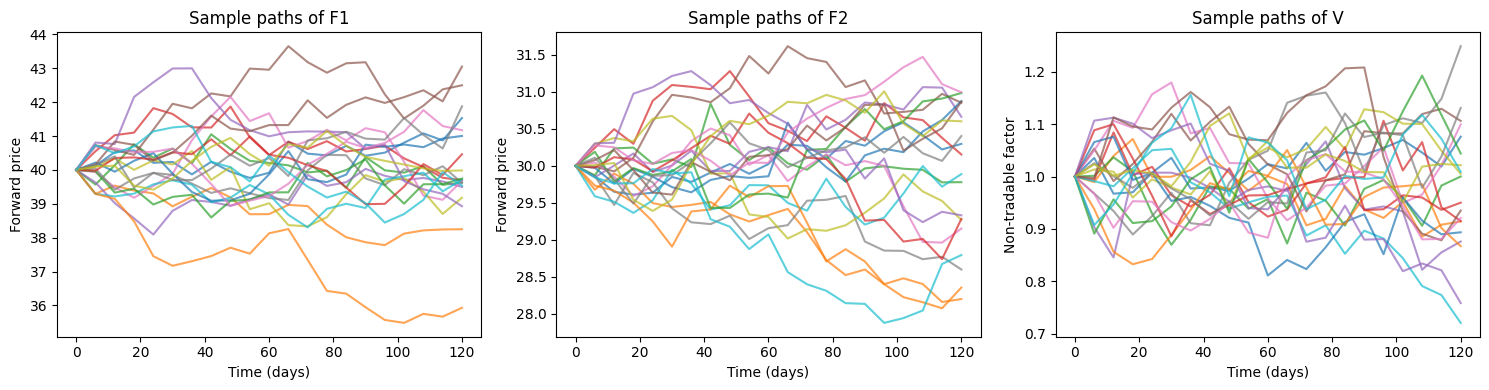

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(20):
    axes[0].plot(time_days, tradable_paths[i, :, 0], alpha=0.7)
axes[0].set_title("Sample paths of F1")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Forward price")

for i in range(20):
    axes[1].plot(time_days, tradable_paths[i, :, 1], alpha=0.7)
axes[1].set_title("Sample paths of F2")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Forward price")

for i in range(20):
    axes[2].plot(time_days, volume_paths[i, :], alpha=0.7)
axes[2].set_title("Sample paths of V")
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("Non-tradable factor")

plt.tight_layout()
plt.show()


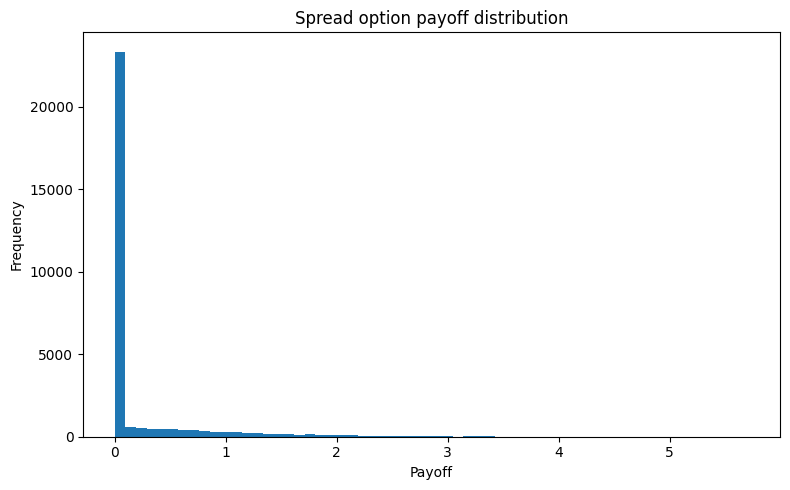

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(payoff, bins=60)
plt.title("Spread option payoff distribution")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Interface specification

The expected model output is the matrix of hedging positions for the tradable assets.

For a split with `n_paths` trajectories, `N` hedging dates and `d=2` tradable assets,
the expected shape is `(n_paths, N, 2)`.

The element `hedges[i, t, j]` is the position held in tradable asset `j`
on the interval `[t, t+1]` for trajectory `i`.


In [11]:
INTERFACE = {
    "expected_shape": "(n_paths, N, 2)",
    "convention": "hedges[i, t, j] is the position in tradable asset j held on interval [t, t+1] for path i",
    "recommended_files": [
        "hedges_base_test.npy",
        "hedges_asymmetric_loss_test.npy",
        "hedges_transaction_cost_test.npy"
    ],
    "liquidity_constraint": "positions and position increments must satisfy the liquidity bounds stored in config['liquidity']"
}

with open(BASE_DIR / "interface_spec.json", "w", encoding="utf-8") as f:
    json.dump(INTERFACE, f, indent=2)

INTERFACE


{'expected_shape': '(n_paths, N, 2)',
 'convention': 'hedges[i, t, j] is the position in tradable asset j held on interval [t, t+1] for path i',
 'recommended_files': ['hedges_base_test.npy',
  'hedges_asymmetric_loss_test.npy',
  'hedges_transaction_cost_test.npy'],
 'liquidity_constraint': "positions and position increments must satisfy the liquidity bounds stored in config['liquidity']"}

## Financial evaluation pipeline

The functions below evaluate any hedging strategy produced later by the learning model.
Liquidity constraints are checked before computing performance metrics.


In [12]:
def validate_hedges_shape(tradable_paths, hedges):
    n_paths, n_steps_plus_one, d = tradable_paths.shape
    expected_shape = (n_paths, n_steps_plus_one - 1, d)
    if hedges.shape != expected_shape:
        raise ValueError(f"Expected hedges shape {expected_shape}, got {hedges.shape}")


def check_liquidity_constraints(hedges, liquidity, tol=1e-6):
    # tolérance 1e-6 pour absorber les écarts float32 → float64 (≈ 6e-9 sur 0.15)
    liquidity = np.asarray(liquidity, dtype=float)
    if np.any(np.abs(hedges[:, 0, :]) > liquidity + tol):
        raise ValueError("Initial hedge positions violate liquidity constraints.")
    increments = np.diff(hedges, axis=1)
    if np.any(np.abs(increments) > liquidity + tol):
        max_viol = float(np.max(np.abs(increments) - liquidity))
        raise ValueError(f"Hedge increments violate liquidity constraints. "
                         f"Max excess: {max_viol:.2e}")


def compute_terminal_portfolio_value(tradable_paths, hedges, premium=0.0):
    validate_hedges_shape(tradable_paths, hedges)
    increments = tradable_paths[:, 1:, :] - tradable_paths[:, :-1, :]
    gains = np.sum(hedges * increments, axis=(1, 2))
    return premium + gains


def compute_transaction_costs(hedges, transaction_costs):
    transaction_costs = np.asarray(transaction_costs, dtype=float)
    first_trade = np.abs(hedges[:, 0, :])
    later_trades = np.abs(np.diff(hedges, axis=1))
    all_trades = np.concatenate([first_trade[:, None, :], later_trades], axis=1)
    return np.sum(all_trades * transaction_costs[None, None, :], axis=(1, 2))


def compute_hedging_error(tradable_paths, hedges, payoff, premium=0.0):
    terminal_value = compute_terminal_portfolio_value(tradable_paths, hedges, premium=premium)
    return terminal_value - payoff


def compute_net_pnl(tradable_paths, hedges, payoff, premium=0.0, transaction_costs=None):
    terminal_value = compute_terminal_portfolio_value(tradable_paths, hedges, premium=premium)
    costs = 0.0
    if transaction_costs is not None:
        costs = compute_transaction_costs(hedges, transaction_costs)
    return terminal_value - payoff - costs


def summarize_array(x):
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "q01": float(np.quantile(x, 0.01)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.median(x)),
        "q95": float(np.quantile(x, 0.95)),
        "q99": float(np.quantile(x, 0.99)),
        "max": float(np.max(x)),
    }


def print_summary(name, x):
    summary = summarize_array(x)
    print(name)
    for key, value in summary.items():
        print(f"  {key}: {value:.6f}")
    return summary


## Dummy strategy test

This validates the evaluation pipeline before any model output is available.
The dummy strategy is the zero-hedge strategy.


In [13]:
test_tradable = dataset["test"]["tradable_paths"]
test_payoff = dataset["test"]["payoff"]

n_test_paths, n_steps_plus_one, d = test_tradable.shape
N = n_steps_plus_one - 1

dummy_hedges = np.zeros((n_test_paths, N, d), dtype=np.float64)

check_liquidity_constraints(dummy_hedges, CONFIG["liquidity"])

dummy_error = compute_hedging_error(
    tradable_paths=test_tradable,
    hedges=dummy_hedges,
    payoff=test_payoff,
    premium=0.0
)

dummy_net_pnl = compute_net_pnl(
    tradable_paths=test_tradable,
    hedges=dummy_hedges,
    payoff=test_payoff,
    premium=0.0,
    transaction_costs=CONFIG["transaction_costs"]
)

summary_error = print_summary("Dummy hedging error", dummy_error)
summary_net_pnl = print_summary("Dummy net PnL", dummy_net_pnl)


Dummy hedging error
  mean: -0.216662
  std: 0.544795
  min: -4.543742
  q01: -2.511688
  q05: -1.394191
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000
Dummy net PnL
  mean: -0.216662
  std: 0.544795
  min: -4.543742
  q01: -2.511688
  q05: -1.394191
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000


In [14]:
with open(RESULTS_DIR / "dummy_hedging_error_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_error, f, indent=2)

with open(RESULTS_DIR / "dummy_net_pnl_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_net_pnl, f, indent=2)

np.save(RESULTS_DIR / "dummy_hedging_error.npy", dummy_error)
np.save(RESULTS_DIR / "dummy_net_pnl.npy", dummy_net_pnl)

print(f"Dummy evaluation saved in: {RESULTS_DIR.resolve()}")


Dummy evaluation saved in: /Users/user/Desktop/ML/Machine-Learning-in-Finance-Project/deep_hedging_phase1_paper_aligned/results


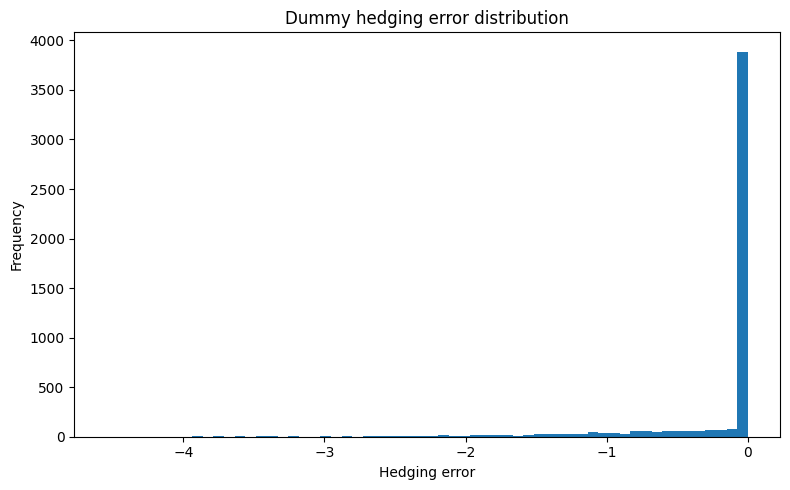

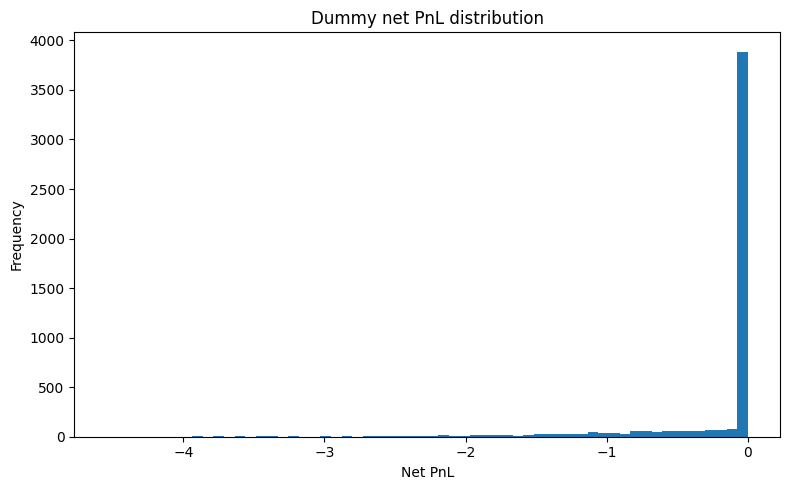

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(dummy_error, bins=60)
plt.title("Dummy hedging error distribution")
plt.xlabel("Hedging error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dummy_net_pnl, bins=60)
plt.title("Dummy net PnL distribution")
plt.xlabel("Net PnL")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Final note

At this stage, the phase 1 dataset is ready and aligned with the paper structure.
The evaluation framework is also ready.
The next step is to plug model-generated hedging strategies into this pipeline.


# Phase 2 – Algorithme Global (Fecamp, Mikael, Warin 2019)

Ce notebook implémente l'**algorithme global** décrit dans l'article.  
L'idée centrale est de formuler la couverture comme un **problème d'optimisation globale** :

$$\theta^* = \arg\min_{\theta} \; L\bigl(X_T(\theta) - g(S_T)\bigr)$$

où $X_T(\theta)$ est la valeur terminale du portefeuille auto-financé paramétré par le réseau de neurones $\theta$, et $g(S_T)$ est le payoff à répliquer (section 2.2 de l'article).

La valeur terminale s'écrit :

$$X_T(\theta) = p(\theta) + \sum_{i=1}^{d} \sum_{j=0}^{N-1} \Delta^i(t_j, (\tilde{S}_{t_k})_{k \leq j}, \theta) \; (F^i_{t_{j+1}} - F^i_{t_j})$$

L'architecture retenue est l'**Augmented LSTM** (section 4.2) : une cellule LSTM suivie de couches feedforward ReLU, qui donne les meilleures performances dans l'article (Table 1 et 2).

In [16]:
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## 1. Chargement des données

On charge le dataset généré en Phase 1 (Case 2 modifié) :
- $d = 2$ actifs tradables : $F^1, F^2$
- $1$ facteur non-tradable : $V$ (risque de volume)
- $N = 20$ dates de couverture, maturité $T = 120$ jours
- Contrainte de liquidité : $l^i = 0.15$ pour tout $i$

Le vecteur d'état est $S_t = (F^1_t, F^2_t, V_t) \in \mathbb{R}^3$.

In [17]:
DATA_DIR = Path("deep_hedging_phase1_paper_aligned/data")
RESULTS_DIR = Path("deep_hedging_phase1_paper_aligned/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

with open(DATA_DIR / "config.json") as f:
    config_raw = json.load(f)

CONFIG = {
    **config_raw,
    "liquidity": np.array(config_raw["liquidity"]),
    "transaction_costs": np.array(config_raw["transaction_costs"]),
}

N       = CONFIG["N"]
d       = 2
liq     = CONFIG["liquidity"]   

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)

train_state    = to_tensor(dataset["train"]["state_paths"])       
train_tradable = to_tensor(dataset["train"]["tradable_paths"])    
train_payoff   = to_tensor(dataset["train"]["payoff"])            

val_state      = to_tensor(dataset["validation"]["state_paths"])
val_tradable   = to_tensor(dataset["validation"]["tradable_paths"])
val_payoff     = to_tensor(dataset["validation"]["payoff"])

test_state     = to_tensor(dataset["test"]["state_paths"])
test_tradable  = to_tensor(dataset["test"]["tradable_paths"])
test_payoff    = to_tensor(dataset["test"]["payoff"])

print("Train state shape:", train_state.shape)
print("Train payoff shape:", train_payoff.shape)

Train state shape: torch.Size([20000, 21, 3])
Train payoff shape: torch.Size([20000])


## 2. Normalisation des états $\tilde{S}_t$

L'article normalise les états avant de les passer au réseau (section 4, équation implicite) :

$$\tilde{S}_t = \frac{S_t - \mathbb{E}[S_t]}{\sqrt{\mathbb{E}[(S_t - \mathbb{E}[S_t])^2]}}$$



Conformément à l'article, on génère **100 000 simulations dédiées** (seed distinct du dataset) uniquement pour calculer les statistiques de normalisation. Ces stats sont ensuite appliquées à train, val et test.



In [18]:
# Config identique mais 100 000 chemins, seed distinct du dataset (seed=42)
norm_config = {
    **{k: (np.array(v) if isinstance(v, list) else v) for k, v in config_raw.items()},
    "n_train": 100_000,
    "n_val":   0,
    "n_test":  0,
    "seed":    0,
}

_, norm_tradable, norm_volume = simulate_paper_like_paths(norm_config)

# Reconstruction du vecteur d'état S = (F1, F2, V) 
norm_state_np = np.concatenate([norm_tradable, norm_volume[..., None]], axis=2)
norm_state_t  = to_tensor(norm_state_np)

state_mean = norm_state_t.mean(dim=0)
state_std  = norm_state_t.std(dim=0).clamp(min=1e-8)

def normalize(state_paths):
    return (state_paths - state_mean) / state_std

train_state_norm = normalize(train_state)
val_state_norm   = normalize(val_state)
test_state_norm  = normalize(test_state)

print("Normalized state mean (should be ~0):", train_state_norm.mean().item())
print("Normalized state std  (should be ~1):", train_state_norm.std().item())

Normalized state mean (should be ~0): 0.001152815530076623
Normalized state std  (should be ~1): 0.9710415601730347


## 3. Architecture : Augmented LSTM

### 3.1 Cellule LSTM classique

L'article utilise les équations LSTM standard (section 3.2, équation 8) :

$$\Gamma^f_t = \sigma(A_f S_t + U_f C_{t-1} + b_f) \qquad \text{(forget gate)}$$
$$\Gamma^i_t = \sigma(A_i S_t + U_i C_{t-1} + b_i) \qquad \text{(input gate)}$$
$$\Gamma^o_t = \sigma(A_o S_t + U_o C_{t-1} + b_o) \qquad \text{(output gate)}$$
$$M_t = \Gamma^f_t \odot M_{t-1} + \Gamma^i_t \odot \tanh(A_M S_t + U_M C_{t-1} + b_M)$$
$$C_t = \Gamma^o_t \odot \tanh(M_t)$$

### 3.2 Augmented LSTM

La sortie $C_t$ est ensuite passée à travers plusieurs couches ReLU feedforward


Paramètres utilisés (section 4.3) :
- LSTM : **50 unités**
- Feedforward : **3 couches ReLU**, densité **10**

In [19]:
class LSTMAug(nn.Module):
    """
    Implémentation de l'Augmented LSTM (Figure 4, section 4.2).

    A chaque date t_j, reçoit :
      - tilde_S_t : état normalisé (batch, state_dim)
      - Delta_prev : position courante (batch, d) -- utilisée pour la contrainte tanh
      - (h, c) : états cachés LSTM

    Produit :
      - Delta_t : nouvelle position (batch, d), bornée dans [-liq, liq] via tanh (eq. 13)
    """

    def __init__(self, state_dim=3, d=2, lstm_units=50, ff_layers=3, ff_width=10, liq=None):
        super().__init__()
        self.d = d
        self.lstm_units = lstm_units

        # Liquidité 
        if liq is None:
            liq = torch.ones(d)
        self.register_buffer("liq", torch.tensor(liq, dtype=torch.float32))

        # Cellule LSTM prend (tilde_S, Delta_prev) en entrée
        self.lstm = nn.LSTMCell(input_size=state_dim + d, hidden_size=lstm_units)

        # Feedforward  3 ReLU après la cellule LSTM
        layers = []
        in_dim = lstm_units
        for _ in range(ff_layers - 1):
            layers += [nn.Linear(in_dim, ff_width), nn.ReLU()]
            in_dim = ff_width
        layers += [nn.Linear(in_dim, d)] 
        self.feedforward = nn.Sequential(*layers)

        # Premium p(theta) variable entraînable
        self.premium = nn.Parameter(torch.zeros(1))

    def init_hidden(self, batch_size):
        h = torch.zeros(batch_size, self.lstm_units, device=self.liq.device)
        c = torch.zeros(batch_size, self.lstm_units, device=self.liq.device)
        return h, c

    def forward(self, state_norm, tradable_paths):
        """
        Déroule la stratégie sur tous les pas de temps.

        state_norm    : (batch, N+1, state_dim)  -- états normalisés tilde_S
        tradable_paths: (batch, N+1, d)          -- prix non normalisés F^i

        Retourne :
          X_T   : (batch,)    -- valeur terminale du portefeuille
          deltas : (batch, N, d) -- positions à chaque date
        """
        batch = state_norm.shape[0]
        N_steps = state_norm.shape[1] - 1

        h, c = self.init_hidden(batch)

        delta = torch.zeros(batch, self.d, device=self.liq.device)

        X = self.premium.expand(batch)   
        all_deltas = []

        for t in range(N_steps):
            s_t = state_norm[:, t, :]          
            inp = torch.cat([s_t, delta], dim=1) 

            h, c = self.lstm(inp, (h, c))
            command = self.feedforward(h)      

   
            delta = delta + self.liq * torch.tanh(command)

            all_deltas.append(delta.unsqueeze(1))

            # Gain sur l'intervalle [t, t+1]
            dF = tradable_paths[:, t+1, :] - tradable_paths[:, t, :]  
            X = X + (delta * dF).sum(dim=1)

        deltas = torch.cat(all_deltas, dim=1)  
        return X, deltas

## 4. Fonctions de perte

L'article teste trois critères (section 2.2). On pose $Y_T = X_T - g(S_T)$.

### 4.1 Mean Squared Error (équation 4)

$$L_{\text{MSE}}(Y) = \mathbb{E}[Y^2]$$

Critère symétrique : pénalise identiquement les pertes et les gains.

### 4.2 Perte asymétrique — variante

$$L^\alpha_{\text{asym}}(Y) = \mathbb{E}\bigl[(1+\alpha)Y^2 \mathbf{1}_{Y \leq 0} + Y^2 \mathbf{1}_{Y \geq 0}\bigr]$$

Pour $\alpha > 0$, les **pertes** ($Y < 0$) sont plus pénalisées que les gains.
L'article montre que ce critère réduit les queues de pertes extrêmes (Figures 9-11).

In [20]:
def loss_mse(Y):
    return (Y ** 2).mean()


def loss_asymmetric(Y, alpha=1.0):
    loss_neg = (1.0 + alpha) * (Y ** 2) * (Y <= 0).float()
    loss_pos = (Y ** 2) * (Y > 0).float()
    return (loss_neg + loss_pos).mean()


LOSS_FUNCTIONS = {
    "mse":        loss_mse,
    "asymmetric": lambda Y: loss_asymmetric(Y, alpha=1.0),
}


## 5. Boucle d'entraînement

On suit l'**Algorithme 1** de l'article (section 3.3) basé sur Adam :

- **Batch size** : 50 
- **Learning rate** Adam : 0.001
- **Nombre d'itérations** : 20 000
- Tous les 1 000 pas, on sauvegarde le meilleur modèle selon la loss sur le jeu de validation


In [21]:
def make_dataloader(state_norm, tradable, payoff, batch_size):
    dataset = torch.utils.data.TensorDataset(state_norm, tradable, payoff)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)


def train_model(
    model,
    loss_fn,
    train_state_norm,
    train_tradable,
    train_payoff,
    val_state_norm,
    val_tradable,
    val_payoff,
    n_iter=20_000,
    batch_size=50,
    lr=1e-3,
    checkpoint_every=1_000,
    verbose=True,
):
    optimizer   = torch.optim.Adam(model.parameters(), lr=lr)
    loader      = make_dataloader(train_state_norm, train_tradable, train_payoff, batch_size)
    loader_iter = iter(loader)

    best_val_loss, best_state = float("inf"), None
    train_losses, val_losses  = [], []

    model.train()

    for iteration in range(1, n_iter + 1):
        try:
            s_batch, f_batch, p_batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            s_batch, f_batch, p_batch = next(loader_iter)

        optimizer.zero_grad()
        X_T, _ = model(s_batch, f_batch)
        Y      = X_T - p_batch
        loss   = loss_fn(Y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if iteration % checkpoint_every == 0:
            model.eval()
            with torch.no_grad():
                X_val, _ = model(val_state_norm, val_tradable)
                Y_val    = X_val - val_payoff
                val_loss = loss_fn(Y_val).item()
            val_losses.append((iteration, val_loss))
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            if verbose:
                print(f"Iter {iteration:6d} | train loss: {loss.item():.6f} | val loss: {val_loss:.6f}")
            model.train()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses


## 6. Entraînement : modèle de base (MSE) et variante asymétrique

On entraîne deux modèles avec l'**Augmented LSTM** :
- **Modèle de base** : loss MSE — référence principale
- **Variante** : loss asymétrique (α=1) — pour comparer les queues de distribution


In [ ]:
N_ITER      = 10000
BATCH_SIZE  = 50
LR          = 1e-3
LSTM_UNITS  = 50
FF_LAYERS   = 3
FF_WIDTH    = 10

trained_models = {}
all_train_losses = {}
all_val_losses   = {}

for loss_name, loss_fn in LOSS_FUNCTIONS.items():
    print(f"\n{'='*50}")
    print(f"Entraînement avec loss : {loss_name}")
    print(f"{'='*50}")

    model = LSTMAug(
        state_dim=3,
        d=d,
        lstm_units=LSTM_UNITS,
        ff_layers=FF_LAYERS,
        ff_width=FF_WIDTH,
        liq=liq,
    ).to(DEVICE)

    model, t_losses, v_losses = train_model(
        model=model,
        loss_fn=loss_fn,
        train_state_norm=train_state_norm,
        train_tradable=train_tradable,
        train_payoff=train_payoff,
        val_state_norm=val_state_norm,
        val_tradable=val_tradable,
        val_payoff=val_payoff,
        n_iter=N_ITER,
        batch_size=BATCH_SIZE,
        lr=LR,
    )

    trained_models[loss_name]   = model
    all_train_losses[loss_name] = t_losses
    all_val_losses[loss_name]   = v_losses

    torch.save(model.state_dict(), RESULTS_DIR / f"model_{loss_name}.pt")
    print(f"Modèle sauvegardé : model_{loss_name}.pt")


Entraînement avec loss : mse
Iter   1000 | train loss: 0.029171 | val loss: 0.042451
Iter   2000 | train loss: 0.019659 | val loss: 0.028025
Modèle sauvegardé : model_mse.pt

Entraînement avec loss : asymmetric
Iter   1000 | train loss: 0.038800 | val loss: 0.065039
Iter   2000 | train loss: 0.024163 | val loss: 0.041546
Modèle sauvegardé : model_asymmetric.pt


## 7. Courbes de loss (train / validation)



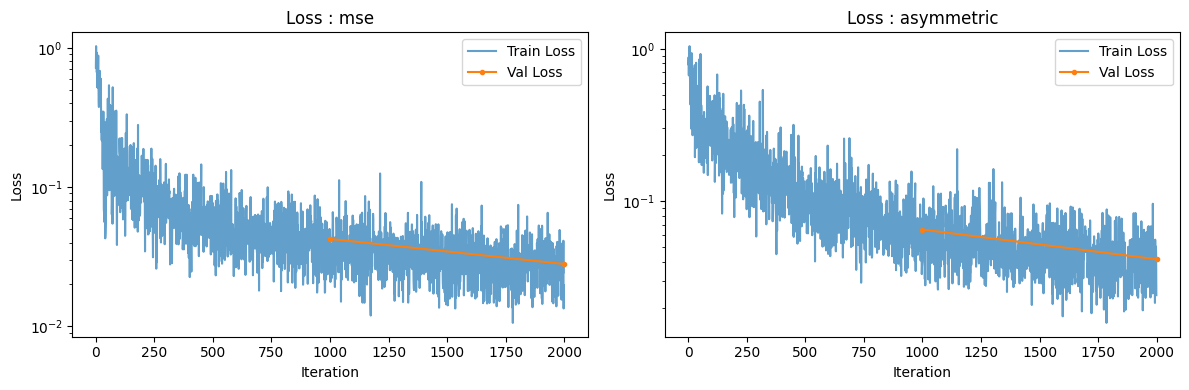

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (loss_name, t_losses) in zip(axes, all_train_losses.items()):
    ax.plot(t_losses, label="Train Loss", alpha=0.7)
    iters_val = [v[0] for v in all_val_losses[loss_name]]
    vals_val  = [v[1] for v in all_val_losses[loss_name]]
    ax.plot(iters_val, vals_val, label="Val Loss", marker="o", markersize=3)
    ax.set_title(f"Loss : {loss_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.set_yscale("log")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "loss_curves.png", dpi=150)
plt.show()


## 8. Évaluation sur le test set

On évalue les deux modèles (base MSE et variante asymétrique) sur les données de test :
- **MSE** : $\mathbb{E}[Y_T^2]$ (métrique de comparaison, Table 3 de l'article)
- La **distribution de $Y_T$** pour comparer les deux critères (Figures 9-11)


In [33]:
test_errors   = {}
deltas_by_loss = {}

for loss_name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        X_T, deltas = model(test_state_norm, test_tradable)
        Y_T = X_T - test_payoff

    Y_np      = Y_T.cpu().numpy()
    deltas_np = deltas.cpu().numpy()
    test_errors[loss_name]    = Y_np
    deltas_by_loss[loss_name] = deltas_np

    try:
        check_liquidity_constraints(deltas_np, CONFIG["liquidity"])
        liq_ok = "OK"
    except ValueError as e:
        liq_ok = f"VIOLATION: {e}"

    mse = float((Y_T ** 2).mean().cpu())
    print(f"{loss_name:15s} | MSE test: {mse:.6f} | mean Y: {Y_np.mean():.4f} | std Y: {Y_np.std():.4f} | liquidité: {liq_ok}")

    np.save(RESULTS_DIR / f"hedging_errors_{loss_name}.npy", Y_np)
    np.save(RESULTS_DIR / f"deltas_{loss_name}.npy", deltas_np)


mse             | MSE test: 0.025989 | mean Y: 0.0039 | std Y: 0.1612 | liquidité: OK
asymmetric      | MSE test: 0.029181 | mean Y: 0.0443 | std Y: 0.1650 | liquidité: OK


## 9. Comparaison des distributions de $Y_T$

Reproduction partielle des Figures 9-11 de l'article : on compare les distributions
de l'erreur de couverture entre le modèle de base (MSE) et la variante asymétrique.

L'article observe que la loss asymétrique **réduit les queues gauches** (pertes extrêmes)
au prix de légèrement plus de masse autour de zéro.

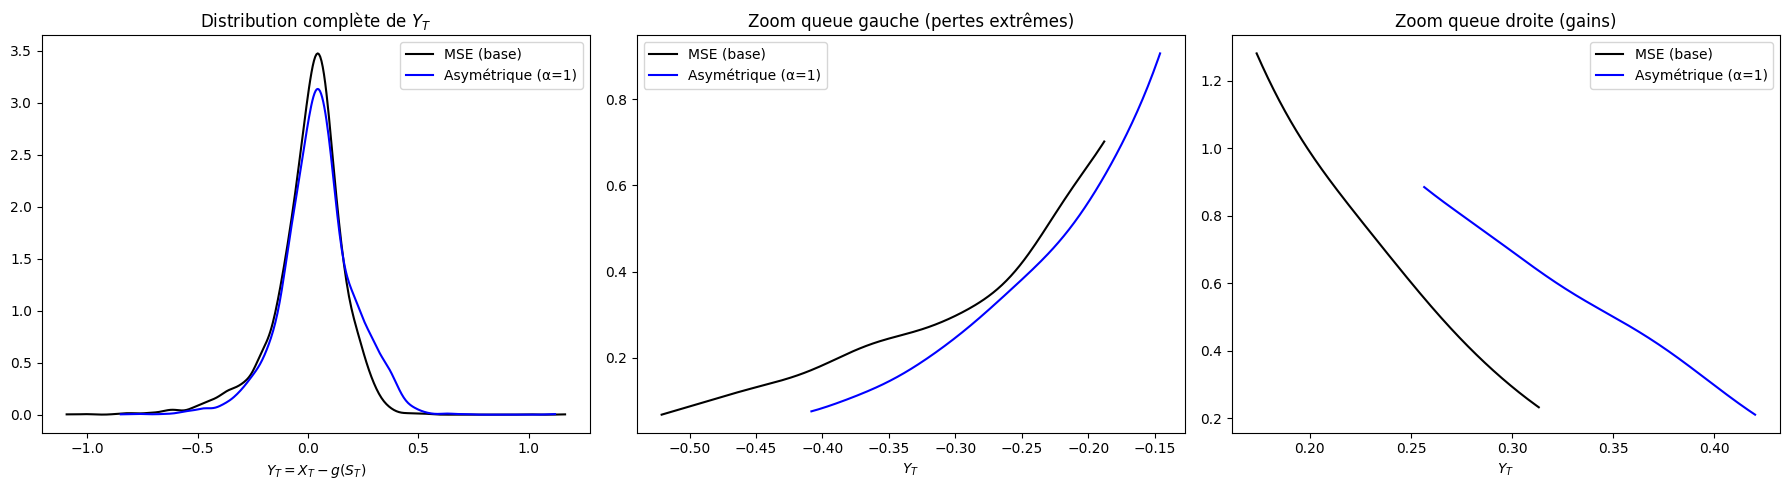

In [34]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"mse": "black", "asymmetric": "blue"}
labels = {"mse": "MSE (base)", "asymmetric": "Asymétrique (α=1)"}

# Distribution globale
ax = axes[0]
for name, Y in test_errors.items():
    kde = gaussian_kde(Y)
    x   = np.linspace(Y.min(), Y.max(), 400)
    ax.plot(x, kde(x), color=colors[name], label=labels[name])
ax.set_title("Distribution complète de $Y_T$")
ax.set_xlabel("$Y_T = X_T - g(S_T)$")
ax.legend()

# queue gauche
ax = axes[1]
for name, Y in test_errors.items():
    q01, q10 = np.quantile(Y, 0.01), np.quantile(Y, 0.10)
    kde = gaussian_kde(Y)
    x   = np.linspace(q01, q10, 200)
    ax.plot(x, kde(x), color=colors[name], label=labels[name])
ax.set_title("Zoom queue gauche (pertes extrêmes)")
ax.set_xlabel("$Y_T$")
ax.legend()

# queue droite
ax = axes[2]
for name, Y in test_errors.items():
    q90, q99 = np.quantile(Y, 0.90), np.quantile(Y, 0.99)
    kde = gaussian_kde(Y)
    x   = np.linspace(q90, q99, 200)
    ax.plot(x, kde(x), color=colors[name], label=labels[name])
ax.set_title("Zoom queue droite (gains)")
ax.set_xlabel("$Y_T$")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "distributions_comparison.png", dpi=150)
plt.show()

## 10. Sauvegarde des hedges de référence

Génération des fichiers de hedging au format final pour le pipeline d'évaluation.
- `hedges_base_test.npy` : positions du modèle de base (LSTM + MSE) sur le test set
- `hedges_asymmetric_test.npy` : positions de la variante asymétrique sur le test set

Shape : `(n_paths, N, d)` = `(5000, 20, 2)` — convention `hedges[i, t, j]`.

In [35]:
deltas_base_np = deltas_by_loss["mse"]
deltas_asym_np = deltas_by_loss["asymmetric"]

np.save(OUTPUT_DIR / "hedges_base_test.npy",       deltas_base_np)
np.save(OUTPUT_DIR / "hedges_asymmetric_test.npy", deltas_asym_np)

print(f"hedges_base_test.npy       shape: {deltas_base_np.shape}  dtype: {deltas_base_np.dtype}")
print(f"hedges_asymmetric_test.npy shape: {deltas_asym_np.shape}  dtype: {deltas_asym_np.dtype}")
print(f"Sauvegardés dans : {OUTPUT_DIR.resolve()}")


hedges_base_test.npy       shape: (5000, 20, 2)  dtype: float32
hedges_asymmetric_test.npy shape: (5000, 20, 2)  dtype: float32
Sauvegardés dans : /Users/user/Desktop/ML/Machine-Learning-in-Finance-Project/deep_hedging_phase1_paper_aligned/model_outputs


## 11. Synthèse — Modèle de référence et outputs



### Fichiers de sortie

| Fichier | Description | Shape |
|---|---|---|
| `model_outputs/hedges_base_test.npy` | Hedges modèle de base (LSTM + MSE) sur test set | `(5000, 20, 2)` |
| `model_outputs/hedges_asymmetric_test.npy` | Hedges variante asymétrique sur test set | `(5000, 20, 2)` |

Convention : `hedges[i, t, j]` = position dans l'actif tradable `j` sur l'intervalle `[t, t+1]` pour le chemin `i`.

In [37]:
print("=== Modèle de référence ===")
print(f"Config     : {CONFIG['case_name']}")
print(f"Arch       : Augmented LSTM  (lstm_units={LSTM_UNITS}, ff_layers={FF_LAYERS}, ff_width={FF_WIDTH})")
print(f"Loss base  : MSE")
print()

hedges_base = np.load(OUTPUT_DIR / "hedges_base_test.npy")
hedges_asym = np.load(OUTPUT_DIR / "hedges_asymmetric_test.npy")

print(f"hedges_base_test.npy       : shape={hedges_base.shape}, dtype={hedges_base.dtype}")
print(f"hedges_asymmetric_test.npy : shape={hedges_asym.shape}, dtype={hedges_asym.dtype}")

mse_base     = float(np.mean(np.load(RESULTS_DIR / "hedging_errors_mse.npy") ** 2))
mse_asym     = float(np.mean(np.load(RESULTS_DIR / "hedging_errors_asymmetric.npy") ** 2))
unhedged_mse = float(np.mean(dataset["test"]["payoff"] ** 2))

print()
print(f"MSE modèle de base       : {mse_base:.6f}  ({mse_base/unhedged_mse*100:.2f}% du non-hedgé)")
print(f"MSE variante asymétrique : {mse_asym:.6f}  ({mse_asym/unhedged_mse*100:.2f}% du non-hedgé)")


=== Modèle de référence ===
Config     : paper_case2_modified
Arch       : Augmented LSTM  (lstm_units=50, ff_layers=3, ff_width=10)
Loss base  : MSE

hedges_base_test.npy       : shape=(5000, 20, 2), dtype=float32
hedges_asymmetric_test.npy : shape=(5000, 20, 2), dtype=float32

MSE modèle de base       : 0.025989  (7.56% du non-hedgé)
MSE variante asymétrique : 0.029181  (8.49% du non-hedgé)
